In [60]:
import numpy as np
from tqdm.notebook import tqdm
import pickle
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Functions

In [36]:
def _reform_data_from_dict(data, flatten=True):
    """Helper func for calculate metrics: reformat predictions and labels from dicts. """

    sort_data = sorted(data.items(), key=lambda x: x[0])
    sort_data = [i[1] for i in sort_data]
    sort_data = torch.cat(sort_data, dim=0)

    if flatten:
        sort_data = np.reshape(sort_data.cpu(), (-1))
    else:
        sort_data = np.array(sort_data.cpu())

    return sort_data

In [37]:
def calculate_signal_stats(signal, fs):
    """
    Calculates the basic statistics we're using for comparison in BP metrics.
    Mean, Mean SE, Max, Max SE, Min, Min SE
    Args:
        signal (torch.Tensor): The input signal tensor.
        fs (int): Sampling frequency of the signal.
    Returns:
        stat_dict (dict): A dictionary containing the calculated statistics.
        """
    width = signal.shape[0]//fs
    mean = torch.mean(signal)
    mean_standard_error = torch.std(signal) / np.sqrt(len(signal))
    _, max_values = find_peaks(signal, type='max', width=width)
    max = torch.mean(torch.tensor(max_values))
    max_standard_error = torch.std(torch.tensor(max_values)) / np.sqrt(len(max_values))
    _, min_values = find_peaks(signal, type='min', width=width)
    min = torch.mean(torch.tensor(min_values))
    min_standard_error = torch.std(torch.tensor(min_values)) / np.sqrt(len(min_values))
    stat_dict = {
        "mean": mean.item(),
        "mean_se": mean_standard_error.item(),
        "max": max.item(),
        "max_se": max_standard_error.item(),
        "min": min.item(),
        "min_se": min_standard_error.item()
    }
    return stat_dict

In [38]:
def find_peaks(trace: np.ndarray|torch.Tensor, type='max', width=31, print_warning=False) -> tuple:
    "Uses pytorch to find peaks within window of nominal width"
    if isinstance(trace, np.ndarray):
        trace = torch.tensor(trace)
    if type == 'max':
        window_extrema = torch.nn.functional.max_pool1d_with_indices(trace.view(1,1,-1), torch.Size([width]), 1, padding=torch.Size([width//2]))[1].squeeze()
    elif type == 'min':
        window_extrema = torch.nn.functional.max_pool1d_with_indices(-1*trace.view(1,1,-1), torch.Size([width]), 1, padding=torch.Size([width//2]))[1].squeeze()
    else:
        raise TypeError("type can only be 'max' or 'min'")
    if width%2 != 1:
        width += 1  # ensure width is odd
        if print_warning:
            print(f"Warning: width must be odd, incremented to {width}")
    candidates = window_extrema.unique()
    cleaned_idx = candidates[(window_extrema[candidates]==candidates).nonzero()].numpy().squeeze()
    cleaned_values = trace[cleaned_idx].numpy().squeeze()
    return cleaned_idx, cleaned_values

In [39]:
def unnormalize_signal(signal, min, max):
    raw_sig = (signal + 1) / 2 * (max - min) + min
    return raw_sig

In [40]:
def mean_se(z: np.ndarray | torch.Tensor, kernel: str = 'QS', fs: int = 30, n_sec: int = 5) -> tuple[float, float]:
    """
    Calculate mean and HAC standard error for physiological 1D signal.
    Args: z (array/tensor), kernel ('QS'/'Bartlett'/'Parzen'), fs (sampling rate Hz), n_sec (bandwidth seconds)
    Returns: (mean, HAC standard error) as floats
    """
    if isinstance(z, np.ndarray):
        z = torch.tensor(z, dtype=torch.float32)
    elif not isinstance(z, torch.Tensor):
        z = torch.tensor(z, dtype=torch.float32)
    
    T = z.size(0)
    m = z.mean()
    q = fs * n_sec
    cz = z - m
    gamma0 = torch.dot(cz, cz) / T
    var = gamma0
    
    for k in range(1, q + 1):
        if kernel == 'Bartlett':
            w = 1.0 - k / (q + 1.0)
        elif kernel == 'QS':
            x = k / (q + 1.0)
            w = 25.0 / (12.0 * np.pi**2 * x**2) * (np.sin(6.0 * np.pi * x / 5.0) / (6.0 * np.pi * x / 5.0) - np.cos(6.0 * np.pi * x / 5.0))
        elif kernel == 'Parzen':
            x = k / (q + 1.0)
            w = 2.0 * (1.0 - x)**3 if x > 0.5 else 1.0 - 6.0 * x**2 + 6.0 * x**3
        else:
            raise ValueError(f"Unknown kernel: {kernel}. Use 'Bartlett', 'QS', or 'Parzen'")
        
        gk = torch.dot(cz[k:], cz[:-k]) / T
        var += 2.0 * w * gk
    
    se = torch.sqrt(var / T)
    return float(m), float(se)

In [41]:
def _delta_se(gprime: float, se_base: float) -> float:
    return abs(gprime) * se_base

In [42]:
def _moving_block_bootstrap(stat_fn, pred: np.ndarray | torch.Tensor, label: np.ndarray | torch.Tensor, B: int = 500) -> float:
    """
    Calculate bootstrap standard error using moving block bootstrap.
    Args: stat_fn (callable), pred (array/tensor), label (array/tensor), B (bootstrap samples)
    Returns: standard error as float
    """
    if isinstance(pred, torch.Tensor):
        pred = pred.detach().cpu().numpy()
    elif not isinstance(pred, np.ndarray):
        pred = np.array(pred)
    
    if isinstance(label, torch.Tensor):
        label = label.detach().cpu().numpy()
    elif not isinstance(label, np.ndarray):
        label = np.array(label)
    
    T = pred.size
    L = max(2, int(round(T ** (1/3))))
    n_blocks = int(np.ceil(T / L))
    vals = np.empty(B, dtype=np.float32)
    
    for b in range(B):
        idx = []
        for _ in range(n_blocks):
            start = np.random.randint(0, T - L + 1)
            idx.extend(range(start, start + L))
        idx = idx[:T]
        vals[b] = stat_fn(pred[idx], label[idx])
    
    return float(np.std(vals, ddof=1))

In [43]:
def get_mean_bias(pred: np.ndarray | torch.Tensor, label: np.ndarray | torch.Tensor) -> dict:
    """
    Calculate mean bias (systematic error) between predictions and labels.
    Args: pred (array/tensor), label (array/tensor)
    Returns: dict with 'value' (mean bias) and 'se' (standard error)
    """
    if isinstance(pred, np.ndarray):
        pred = torch.tensor(pred, dtype=torch.float32)
    if isinstance(label, np.ndarray):
        label = torch.tensor(label, dtype=torch.float32)
    
    e = pred - label
    m, se = mean_se(e)
    return {"value": m, "se": se}


In [44]:
def get_mean_levels(pred: np.ndarray | torch.Tensor, label: np.ndarray | torch.Tensor) -> dict:
    """
    Compare mean levels of predicted vs actual signals with bias.
    Args: pred (array/tensor), label (array/tensor)
    Returns: dict with pred_mean, label_mean, bias, bias_se
    """
    if isinstance(pred, np.ndarray):
        pred = torch.tensor(pred, dtype=torch.float32)
    if isinstance(label, np.ndarray):
        label = torch.tensor(label, dtype=torch.float32)
    
    mp, _ = mean_se(pred)
    ml, _ = mean_se(label)
    bias = get_mean_bias(pred, label)
    return {"pred_mean": mp, "label_mean": ml, "bias": bias["value"], "bias_se": bias["se"]}

In [45]:
def get_peak_bias(pred: np.ndarray | torch.Tensor, label: np.ndarray | torch.Tensor, peak_type: str = 'max', fs: int = 30, independent: bool = False) -> dict:
    """
    Calculate bias between peak values (max or min) of predicted vs actual signals.
    Args: pred (array/tensor), label (array/tensor), peak_type ('max'/'min'), fs (sampling rate Hz)
    Returns: dict with 'value' (mean peak bias) and 'se' (standard error)
    """
    if isinstance(pred, np.ndarray):
        pred = torch.tensor(pred, dtype=torch.float32)
    if isinstance(label, np.ndarray):
        label = torch.tensor(label, dtype=torch.float32)

    _, pred_vals = find_peaks(trace=pred, type=peak_type, width=fs)
    _, label_vals = find_peaks(trace=label, type=peak_type, width=fs)

    if len(pred_vals) == 0 or len(label_vals) == 0:
        return {"value": float("nan"), "se": float("nan")}
    
    if independent:
        # Option 1: Simple standard error (assumes independence)
        mp = float(np.mean(pred_vals))
        ml = float(np.mean(label_vals))
        sep = float(np.std(pred_vals, ddof=1) / np.sqrt(len(pred_vals)))
        sel = float(np.std(label_vals, ddof=1) / np.sqrt(len(label_vals)))
    else:
        # Option 2: If you want to account for autocorrelation in peaks
        mp, sep = mean_se(pred_vals, fs=1, n_sec=10)  # Treat as ~1Hz signal
        ml, sel = mean_se(label_vals, fs=1, n_sec=10)
    se_bias = np.sqrt(sep**2 + sel**2)
    return {"value": mp - ml, "se": float(se_bias)}

In [46]:
def get_rmse(pred: np.ndarray | torch.Tensor, label: np.ndarray | torch.Tensor) -> dict:
    e2 = (pred - label) ** 2
    m, se_m = mean_se(e2)
    val = np.sqrt(m)
    se = _delta_se(0.5 / max(val, np.finfo(float).eps), se_m)
    return {"value": float(val), "se": float(se)}

In [47]:
def get_mae(pred: np.ndarray | torch.Tensor, label: np.ndarray | torch.Tensor) -> dict:
    if isinstance(pred, torch.Tensor):
        pred = pred.detach().cpu().numpy()
    if isinstance(label, torch.Tensor):
        label = label.detach().cpu().numpy()
    ae = np.abs(pred - label)
    m, se = mean_se(ae)
    return {"value": m, "se": se}

In [48]:
def get_pearson_r(pred: np.ndarray | torch.Tensor, label: np.ndarray | torch.Tensor) -> dict:
    if isinstance(pred, torch.Tensor):
        pred = pred.detach().cpu().numpy()
    if isinstance(label, torch.Tensor):
        label = label.detach().cpu().numpy()
    r = float(np.corrcoef(pred, label)[0, 1]) if pred.size > 1 else np.nan
    if np.isnan(r):
        return {"value": np.nan, "se": np.nan}
    def _r(a,b): return float(np.corrcoef(a,b)[0,1]) if a.size>1 else np.nan
    se = _moving_block_bootstrap(_r, pred, label)
    return {"value": r, "se": se}

In [49]:
def get_ccc(pred: np.ndarray | torch.Tensor, label: np.ndarray | torch.Tensor) -> dict:
    if isinstance(pred, torch.Tensor):
        pred = pred.detach().cpu().numpy()
    if isinstance(label, torch.Tensor):
        label = label.detach().cpu().numpy()
    mx, my = pred.mean(), label.mean()
    vx, vy = pred.var(ddof=1), label.var(ddof=1)
    r = float(np.corrcoef(pred, label)[0, 1]) if pred.size > 1 else np.nan
    if np.isnan(r):
        return {"value": np.nan, "se": np.nan}
    val = 2 * r * np.sqrt(vx * vy) / (vx + vy + (mx - my)**2)
    def _ccc(a,b):
        ma, mb = a.mean(), b.mean()
        va, vb = a.var(ddof=1), b.var(ddof=1)
        rr = float(np.corrcoef(a,b)[0,1]) if a.size>1 else np.nan
        return 2 * rr * np.sqrt(va * vb) / (va + vb + (ma - mb)**2)
    se = _moving_block_bootstrap(_ccc, pred, label)
    return {"value": float(val), "se": se}

# Testing

In [168]:
# output_file = "/Users/20759193/repos/rPPG-Toolbox/runs/physhydra/CVP_RGB_H128_W128_CHUNK128_DIFFNORM_CCC/saved_test_outputs/NECKFLIX_CVP_PHYSHYDRA_RGB_DIFFNORM_outputs.pickle"
output_file = "/Users/20759193/repos/rPPG-Toolbox/runs/physhydra/ABP_RGB_H128_W128_CHUNK128_DIFFNORM/saved_test_outputs/NECKFLIX_ABP_PHYSHYDRA_RGB_DIFFNORM_outputs.pickle"
with open(output_file, "rb") as f:
    data = pickle.load(f)

sig_type = 'abp'
if sig_type == 'abp':
    min_p = -50
    max_p = 200
elif sig_type == 'cvp':
    min_p = -30
    max_p = 40
elif sig_type == 'ecg':
    min_p = -1500
    max_p = 1500
else:
    raise ValueError("Signal type not recognized for unnormalization")

data.keys()
predictions = data["predictions"]
labels = data["labels"]
fs = data["fs"]
dicts = []
for index in tqdm(predictions.keys(), ncols=80):
    prediction = unnormalize_signal(_reform_data_from_dict(predictions[index]), min_p, max_p).detach().cpu().numpy()
    _, pred_max_vals = find_peaks(trace=prediction, type='max', width=fs)
    _, pred_min_vals = find_peaks(trace=prediction, type='min', width=fs)
    label = unnormalize_signal(_reform_data_from_dict(labels[index]), min_p, max_p).detach().cpu().numpy()
    _, label_max_vals = find_peaks(trace=label, type='max', width=fs)
    _, label_min_vals = find_peaks(trace=label, type='min', width=fs)
    participant, session, _, posture, substr = index.split('_')
    depth, camera, channels, trace = substr.split('-')
    dicts.append({
        'trace': trace,
        'index': index,
        'recording': index.split('-')[0],
        'participant': participant,
        'session': "_".join([participant, session]),
        'posture': posture,
        'depth': bool(depth == 'D'),
        'camera': camera,
        'channels': channels,
        'prediction': prediction,
        'pred_max_vals': pred_max_vals,
        'pred_min_vals': pred_min_vals,
        'label': label,
        'label_max_vals': label_max_vals,
        'label_min_vals': label_min_vals
    })

df = pd.DataFrame(dicts)

  0%|                                                   | 0/129 [00:00<?, ?it/s]

In [188]:
group_labels = ['index']

grouped = df.groupby(by=group_labels)
results = []

for group_label, group in tqdm(grouped):
    predictions = np.concatenate(group['prediction'].values)
    pred_mean = np.mean(predictions)
    pred_std = np.std(predictions, ddof=1)
    pred_max_vals = np.concatenate(group['pred_max_vals'].values)
    pred_max_mean, pred_max_se = mean_se(pred_max_vals)
    pred_min_vals = np.concatenate(group['pred_min_vals'].values)
    pred_min_mean, pred_min_se = mean_se(pred_min_vals)

    labels = np.concatenate(group['label'].values)
    label_mean = np.mean(labels)
    label_std = np.std(labels, ddof=1)
    label_max_vals = np.concatenate(group['label_max_vals'].values)
    label_max_mean, label_max_se = mean_se(label_max_vals)
    label_min_vals = np.concatenate(group['label_min_vals'].values)
    label_min_mean, label_min_se = mean_se(label_min_vals)

    # Now we look at comparison between prediction and label
    bias_mean, bias_se = get_mean_bias(predictions, labels).values()
    peak_max_bias, peak_max_se = get_peak_bias(predictions, labels, peak_type='max', fs=fs, independent=False).values()
    peak_min_bias, peak_min_se = get_peak_bias(predictions, labels, peak_type='min', fs=fs, independent=False).values()
    # rmse
    rmse_val, rmse_se = get_rmse(predictions, labels).values()
    # mae
    mae_val, mae_se = get_mae(predictions, labels).values()
    # pearson r
    pearson_r_val, pearson_r_se = get_pearson_r(predictions, labels).values()
    # ccc
    ccc_val, ccc_se = get_ccc(predictions, labels).values()

    # add these to our current group dataframe
    d = {'group_label': group_label,
        'pred_mean': pred_mean,
        'pred_std': pred_std,
        'pred_max_mean': pred_max_mean,
        'pred_max_se': pred_max_se,
        'pred_min_mean': pred_min_mean,
        'pred_min_se': pred_min_se,
        'label_mean': label_mean,
        'label_std': label_std,
        'label_max_mean': label_max_mean,
        'label_max_se': label_max_se,
        'label_min_mean': label_min_mean,
        'label_min_se': label_min_se,
        'bias_mean': bias_mean,
        'bias_se': bias_se,
        'peak_max_bias': peak_max_bias,
        'peak_max_se': peak_max_se,
        'peak_min_bias': peak_min_bias,
        'peak_min_se': peak_min_se,
        'rmse_val': rmse_val,
        'rmse_se': rmse_se,
        'mae_val': mae_val,
        'mae_se': mae_se,
        'pearson_r_val': pearson_r_val,
        'pearson_r_se': pearson_r_se,
        'ccc_val': ccc_val,
        'ccc_se': ccc_se
    }
    if group['participant'].nunique() == 1:
        d['participant'] = group['participant'].values[0]
    if group['posture'].nunique() == 1:
        d['posture'] = group['posture'].values[0]
    if group['depth'].nunique() == 1:
        d['depth'] = group['depth'].values[0]
    if group['camera'].nunique() == 1:
        d['camera'] = group['camera'].values[0]
        
    results.append(d)
result_df = pd.DataFrame(results)
result_df.head(2)

  0%|          | 0/129 [00:00<?, ?it/s]

,group_label,pred_mean,pred_std,pred_max_mean,pred_max_se,pred_min_mean,pred_min_se,label_mean,label_std,label_max_mean,...,mae_val,mae_se,pearson_r_val,pearson_r_se,ccc_val,ccc_se,participant,posture,depth,camera
0,"(P027_S01_R1_0_D-K1-RGB-ABP,)",76.453247,21.673286,120.082787,0.023558,52.744621,0.016418,76.402229,21.494078,116.946152,...,9.171759,0.472225,0.815218,0.021008,0.815188,0.020565,P027,0,True,K1
1,"(P027_S01_R1_0_D-K2-RGB-ABP,)",77.967445,20.251730,120.145500,0.028389,55.626194,0.040273,76.375473,21.495028,116.890778,...,9.245206,0.356356,0.825901,0.020576,0.822049,0.020975,P027,0,True,K2


In [187]:
result_df.T

,0
group_label,"(ABP,)"
pred_mean,74.298103
pred_std,19.990601
pred_max_mean,115.061287
pred_max_se,2.021408
pred_min_mean,53.206352
pred_min_se,0.716709
label_mean,70.96817
label_std,25.008413
label_max_mean,118.377495


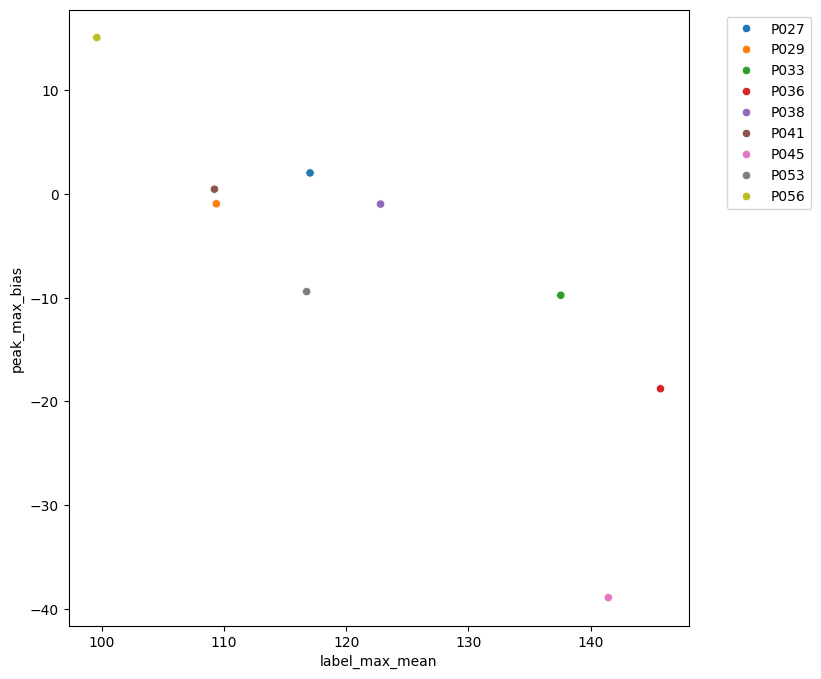

In [183]:
fig, ax = plt.subplots(figsize=(8,8))
# split up group label into separate columns for plotting
# result_df[['participant']] = result_df['group_label'].apply(pd.Series)
sns.scatterplot(data=result_df, x='label_max_mean', y='peak_max_bias',hue='participant', ax=ax)
# add legend but outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.xlim(-2, 14)
# plt.ylim(-10, 10)
plt.show()

In [108]:
result_df = pd.DataFrame(results)
result_df.head()
participant = result_df['recording'].apply(lambda x: x.split('_')[0])
result_df['participant'] = participant
fig, axs = plt.subplots(3,1, figsize=(8,18))
sns.scatterplot(data=result_df, x='pred_mean', y='label_mean', hue='participant', ax=axs[0])
sns.scatterplot(data=result_df, x='pred_max_mean', y='label_max_mean', hue='participant', ax=axs[1])
sns.scatterplot(data=result_df, x='pred_min_mean', y='label_min_mean', hue='participant', ax=axs[2])

KeyError: 'recording'

In [54]:
pd.DataFrame(results[0])

,trace,index,recording,participant,depth,camera,channels,prediction,pred_max_vals,pred_min_vals,...,peak_min_bias,peak_min_se,rmse_val,rmse_se,mae_val,mae_se,pearson_r_val,pearson_r_se,ccc_val,ccc_se
0,ABP,P027_S01_R1_0_D-K1-RGB-ABP,P027_S01_R1_0_D,P027,True,K1,RGB,"[118.07201, 118.88306, 107.25224, 94.9366, 85....","[0.35106438, 0.45448497, 0.4781711, 0.4749639,...","[-0.17057355, -0.18710163, -0.15878624, -0.190...",...,2.034164,0.737321,12.79503,0.303496,9.208482,0.275879,0.81935,0.014593,0.818505,0.015526
1,ABP,P027_S01_R1_0_D-K2-RGB-ABP,P027_S01_R1_0_D,P027,True,K2,RGB,"[107.291016, 105.239716, 94.49747, 86.667435, ...","[0.25832808, 0.4379135, 0.46391833, 0.41858044...","[-0.16658898, -0.15859205, -0.119059324, -0.16...",...,2.034164,0.737321,12.79503,0.303496,9.208482,0.275879,0.81935,0.014593,0.818505,0.015526


In [ ]:
sns.lineplot(y=result['prediction'].values, hue=result['recording'].values)